### interpolacija

podatki so v neenakomernih time frames, zato jih interpoliramo na korake 0.05

In [17]:
import numpy as np
import pandas as pd

def interpolate_flight(df, time_col="Time", step=0.05):
    orig_time = df[time_col].astype(float).to_numpy()
    start, end = orig_time.min(), orig_time.max()
    
    new_time = np.arange(start, end, step)  #ustvarimo nov čas
    
    interp_data = {"Time": new_time}
    for col in df.columns:
        if col != time_col and np.issubdtype(df[col].dtype, np.number):
            interp_data[col] = np.interp(new_time, orig_time, df[col])
    
    return pd.DataFrame(interp_data)


In [18]:
import os

folder_path = r'C:\Users\vsi\Desktop\ijs\smucarski_skoki\project\2024_03_Planica_12_winds\cleaned2'
new_folder = os.path.join(folder_path, "normalized2")

for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)
        df = df.iloc[1:]

        # primer
        interp_df = interpolate_flight(df, time_col="Time", step=0.05)
        #print(interp_df.head())
        cleaned_filename = os.path.splitext(filename)[0] + "_normalized.csv"
        cleaned_path = os.path.join(new_folder, cleaned_filename)
        interp_df.to_csv(cleaned_path, index=False)

In [19]:
print(f"Processing file: {filename}")
print(df.columns)

Processing file: normalized2
Index(['Position', 'Height above ground [m]', 'Time', 'X [m]', 'Y [m]',
       'Z [m]', 'Opening Angle [°]', 'Stalling Angle Left [°]',
       'Stalling Angle Right [°]', 'Roll Angle Left [°]',
       'Roll Angle Right [°]', 'Yaw Angle Left [°]', 'Yaw Angle Right [°]',
       'Speed hor. [km/h]', 'Speed vert. [km/h]', 'Speed resulting [km/h]',
       'W1_Speed', 'W1_Tangent', 'W1_Turbulence', 'W1_CleanTan', 'W1_Cross',
       'W2_Speed', 'W2_Tangent', 'W2_Turbulence', 'W2_CleanTan', 'W2_Cross',
       'W3_Speed', 'W3_Tangent', 'W3_Turbulence', 'W3_CleanTan', 'W3_Cross',
       'W4_Speed', 'W4_Tangent', 'W4_Turbulence', 'W4_CleanTan', 'W4_Cross',
       'W5_Speed', 'W5_Tangent', 'W5_Turbulence', 'W5_CleanTan', 'W5_Cross',
       'W6_Speed', 'W6_Tangent', 'W6_Turbulence', 'W6_CleanTan', 'W6_Cross',
       'W7_Speed', 'W7_Tangent', 'W7_Turbulence', 'W7_CleanTan', 'W7_Cross',
       'W8_Speed', 'W8_Tangent', 'W8_Turbulence', 'W8_CleanTan', 'W8_Cross',
       'W

In [20]:
zones = {
    "takeoff": ["W1", "W2", "W3"],
    "mid":     ["W4", "W5", "W6", "W7"],
    "landing": ["W8", "W9", "W10", "W11", "W12"]
}

wind_features = ["Tangent", "Cross", "Turbulence"]

### preprocessing

In [21]:


def preprocess_flight_normalized(df, step=0.05):
    """
    Preprocess a normalized flight dataframe (already interpolated) to generate states (X), observations (Y), and controls (U).
    
    Args:
        df (pd.DataFrame): Normalized flight dataframe (fixed time step).
        step (float): Time step between rows (used for derivatives).
        
    Returns:
        states (np.ndarray): State matrix [time_steps, state_dim].
        observations (np.ndarray): Observation matrix [time_steps, obs_dim].
        controls (np.ndarray): Control matrix [time_steps, control_dim].
    """

    df.columns = df.columns.str.strip()   #izloči imena stolpcev
    df = df.iloc[1:]
    
    df = df.ffill().bfill()   #back fill za manjkajoče vrednosti
    
    x = df["X [m]"].to_numpy()   #save values
    y = df["Y [m]"].to_numpy()
    z = df["Z [m]"].to_numpy()
    
    dt = step
    vx = np.gradient(x, dt)   #gradient za hitrost
    vy = np.gradient(y, dt)
    vz = np.gradient(z, dt)
    

    states = np.stack([x, y, z, vx, vy, vz], axis=1)   #zgradimo state vector X
    

    roll = df.get("Roll Angle Left [°]", pd.Series([0]*len(x))).to_numpy()
    yaw = df.get("Yaw Angle Left [°]", pd.Series([0]*len(x))).to_numpy()
    speed = np.sqrt(vx**2 + vy**2 + vz**2)
    
    observations = np.stack([x, y, z, roll, yaw, speed], axis=1)   #zgradimo observation vector Y

    zone_feature_avgs = []
    

    for feature in wind_features:
        for zone, sensors in zones.items():
            cols = [f"{sensor}_{feature}" for sensor in sensors if f"{sensor}_{feature}" in df.columns]
            avg_feature = df[cols].mean(axis=1).to_numpy()
            zone_feature_avgs.append(avg_feature)
    
    controls = np.stack(zone_feature_avgs, axis=1)  # shape: (time_steps, 9)
    
    return states, observations, controls


#### preverjanje

In [22]:
#filename = "999_999_Jumper_Anon_ANO_1_20240409-103924_C_OfficialResults_cleaned_normalized.csv"
#df = pd.read_csv(os.path.join(folder_path, filename))
#X, Y, U = preprocess_flight_normalized(df, step=0.05)

določiš katere spremenljivke bodo imele katero vlogo v ssm

In [23]:
import os
import pandas as pd
import numpy as np

normalized_folder = r'C:\Users\vsi\Desktop\ijs\smucarski_skoki\project\2024_03_Planica_12_winds\cleaned\normalized'
combined_output = os.path.join(normalized_folder, "combined_dataset.npz")

X_list, Y_list, U_list = [], [], []

for filename in os.listdir(normalized_folder):
    if filename.endswith('.csv'):
        file_path = os.path.join(normalized_folder, filename)
        df = pd.read_csv(file_path)

        X_state, Y_obs, U_ctrl = preprocess_flight_normalized(df)

        X_list.append(X_state)
        Y_list.append(Y_obs)
        U_list.append(U_ctrl)

        print(f"Processed {filename} -> X:{X_state.shape}, Y:{Y_obs.shape}, U:{U_ctrl.shape}")

# Save combined dataset
np.savez(combined_output, X=np.array(X_list, dtype=object), Y=np.array(Y_list, dtype=object), U=np.array(U_list, dtype=object))
print(f"\nCombined dataset saved to {combined_output}")


Processed 999_999_Jumper_Anon_ANO_1_20240409-102625_C_OfficialResults_cleaned_normalized.csv -> X:(135, 6), Y:(135, 6), U:(135, 9)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102742_C_OfficialResults_cleaned_normalized.csv -> X:(131, 6), Y:(131, 6), U:(131, 9)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102831_C_OfficialResults_cleaned_normalized.csv -> X:(145, 6), Y:(145, 6), U:(145, 9)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102832_C_OfficialResults_cleaned_normalized.csv -> X:(139, 6), Y:(139, 6), U:(139, 9)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102834_C_OfficialResults_cleaned_normalized.csv -> X:(132, 6), Y:(132, 6), U:(132, 9)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102835_C_OfficialResults_cleaned_normalized.csv -> X:(156, 6), Y:(156, 6), U:(156, 9)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102836_C_OfficialResults_cleaned_normalized.csv -> X:(134, 6), Y:(134, 6), U:(134, 9)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102837_C_OfficialResults_cleaned_norma

spraviš v pravo obliko, zaradi lažjega računanja jih spraviš v enotne vektorje

In [24]:
import numpy as np

# Prepare stacked data for system identification
X_t = np.vstack([seq[:-1] for seq in X_list])      # state at time t   
X_next = np.vstack([seq[1:] for seq in X_list])    # state at time t+1  #spustimo 0. da zamaknemo
U_t = np.vstack([u[:-1] for u in U_list])          # control at time t  - matchamo s X_t
Y_t = np.vstack([obs[:-1] for obs in Y_list])      # observation at time t

print(f"X_t: {X_t.shape}, X_next: {X_next.shape}, U_t: {U_t.shape}, Y_t: {Y_t.shape}")


X_t: (26774, 6), X_next: (26774, 6), U_t: (26774, 9), Y_t: (26774, 6)


s pomočjo MNK (metode najmanjšega kvadrata) določimo phi matriko, iz katere ven dobimo A in B matriko

In [ ]:
# Build regression matrix
Phi = np.hstack([X_t, U_t])   # [x_t | u_t]...skupaj sestavimo v eno matriko


Theta, _, _, _ = np.linalg.lstsq(Phi, X_next, rcond=None)  #rešitev po MNK (stabilna verzija)
    #output MNK: matrika A in B, reziduali, rank (A in B), singularnosti (vse razen 1. ignoriramo)
    #ponovimo mnk za vektor, za vsako vrstico v output matriki...MNK za matrike

# Extract A and B
state_dim = X_t.shape[1]
control_dim = U_t.shape[1]
A = Theta[:state_dim, :].T   #prvih state_dim vrstic, vsi stolpci
B = Theta[state_dim:, :].T   #the rest (control_dim)

print("A shape:", A.shape)
print("B shape:", B.shape)


A shape: (6, 6)
B shape: (6, 9)


ponovimo isto, samo da se po liniji vplivov premaknemo dol iz x na y, da lahko dobimo še C in D matriki

In [26]:
Phi_y = np.hstack([X_t, U_t])
Theta_y, _, _, _ = np.linalg.lstsq(Phi_y, Y_t, rcond=None)

obs_dim = Y_t.shape[1]
C = Theta_y[:state_dim, :].T
D = Theta_y[state_dim:, :].T

print("C shape:", C.shape)
print("D shape:", D.shape)


C shape: (6, 6)
D shape: (6, 9)


izračunamo dejansko simulacijo

In [33]:
def simulate_trajectory(x0, U_seq, A, B):
    """
    Simulate trajectory using learned A, B.
    x0: initial state (shape: [state_dim])
    U_seq: control inputs (shape: [T, control_dim])
    """
    X_sim = [x0]  #shrani initial state
    for u in U_seq:                     # @...matrix multiplication
        x_next = A @ X_sim[-1] + B @ u  #Zračuna naslednji korak
        X_sim.append(x_next)            #shrani
    return np.array(X_sim)

# Example: take first flight  (spreminjaš 1. [] pri obeh)
x0 = X_list[4][0]      # first sublist first element
U_seq = U_list[4]      # controls for that flight
X_sim = simulate_trajectory(x0, U_seq, A, B)

print("Simulated trajectory shape:", X_sim.shape)


Simulated trajectory shape: (133, 6)


##### shranjevanje to share

In [28]:
step = 0.05
num_steps = X_state.shape[0]
time_vector = np.arange(num_steps) * step

In [29]:
import numpy as np

# Example matrices
np.savez("ssm_data.npz", 
         A=A, 
         B=B, 
         C=C, 
         D=D, 
         X_sim=X_sim, 
         U=U_seq, 
         time=time_vector)


### plotting

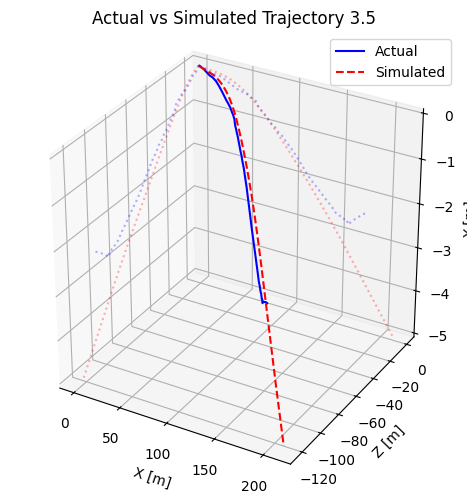

In [34]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


    #(spreminjaš 1. [] v 1. vrstici)
actual = X_list[4][:, :3]   #vzame X,Y,Z iz [x, y, z, vx, vy, vz]
sim = X_sim[:, :3]          # same iz simulacije

Xa = actual[:,0]
Ya = actual[:,1]
Za = actual[:,2]

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection='3d')

ax.plot3D(Xa, Za, Ya, label="Actual", color="blue")
ax.plot3D(sim[:,0], sim[:,2], sim[:,1], label="Simulated", color="red", linestyle="--")


# Ground projections
ax.plot(actual[:, 0], 0,actual[:, 1], color="blue", alpha=0.3, linestyle=':')
ax.plot(sim[:, 0], 0, sim[:, 1], color="red", alpha=0.3, linestyle=':')


ax.plot(0, actual[:, 2], actual[:, 1], color="blue", alpha=0.3, linestyle=':')
ax.plot(0, sim[:, 2],sim[:, 1], color="red", alpha=0.3, linestyle=':')



ax.set_title("Actual vs Simulated Trajectory 3.5")
ax.set_xlabel("X [m]")
ax.set_ylabel("Z [m]")
ax.set_zlabel("Y [m]")
ax.legend()
ax.set_box_aspect([1,1,1])

plt.legend()
plt.tight_layout()
plt.show()


## PINN

==================================================================================================
    it doesn't work yet, like at all ker je nekje touple, maš back up the og normalization so you tried to start again

implementacija PINN (physics-informed neural network...ima vgrajene newtnove zakone and such) s pytorch.
Cilj: izboljšat simulacijo, specifično dolžino skokov. 

In [36]:
pip install torch numpy


  Using cached filelock-3.18.0-py3-none-any.whl.metadata (2.9 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.5-py3-none-any.whl.metadata (6.3 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/241.3 MB ? eta -:--:--
   ---------------------------------------- 0.2/241.3 MB 4.6 MB/s eta 0:00:53
   ---------------------------------------- 0.5/241.3 MB 5.7 MB/s eta 0:00:43
   ---------------------------------------- 0.9/241.3 MB 6.5 MB/s eta 0:00:37
   ---------------------------------------- 1.4/241.3 MB 7.3 MB/s eta 0:00:33
   ---------------------------------------- 1.9/241.3 MB 8.1 MB/s eta 0:00:30
   ---------------------------------------- 2.5/241.3 MB 8.8 MB/s eta 0:00:28
    --------------------------------------- 3.1/241.3 MB 9.3 MB/s eta 0:00:26
    --------------------------------------- 3.7/241.3 MB 9.9 MB/s eta 0:00:24
    --------------------------------------- 4.4/241


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
import torch
from torch.utils.data import Dataset, DataLoader

class SSMFlightDataset(Dataset):
    def __init__(self, X_t, U_t, X_next):
        self.X_t = torch.tensor(X_t, dtype=torch.float32)
        self.U_t = torch.tensor(U_t, dtype=torch.float32)
        self.X_next = torch.tensor(X_next, dtype=torch.float32)

    def __len__(self):
        return len(self.X_t)

    def __getitem__(self, idx):
        return self.X_t[idx], self.U_t[idx], self.X_next[idx]


In [38]:
import torch.nn as nn

class PINNModel(nn.Module):
    def __init__(self, state_dim, control_dim, A, B):
        super().__init__()
        self.A = torch.tensor(A, dtype=torch.float32, requires_grad=False)
        self.B = torch.tensor(B, dtype=torch.float32, requires_grad=False)

        self.residual_net = nn.Sequential(
            nn.Linear(state_dim + control_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, state_dim)
        )

    def forward(self, x, u):
        physics = x @ self.A.T + u @ self.B.T
        residual = self.residual_net(torch.cat([x, u], dim=1))
        return physics + residual


In [83]:
state_dim

159

In [ ]:
#from sklearn.model_selection import train_test_split
#
## Combine everything into a list of triplets
#all_data = list(zip(X_list, Y_list, U_list))
#
## Train/test split
#train_data, test_data = train_test_split(all_data, test_size=0.2, random_state=42)
#
## Unpack
#X_train, Y_train, U_train = map(np.array, zip(*train_data))
#X_test, Y_test, U_test = map(np.array, zip(*test_data))


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (159,) + inhomogeneous part.

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# Flatten lists of arrays into one big array per variable
X_all = np.vstack(X_list)  # shape: (total_timesteps, state_dim)
Y_all = np.vstack(Y_list)  # shape: (total_timesteps, state_dim)
U_all = np.vstack(U_list)  # shape: (total_timesteps, control_dim)

# Train/test split along time dimension
X_train, X_test, Y_train, Y_test, U_train, U_test = train_test_split(
    X_list, Y_list, U_list, test_size=0.2, random_state=42
)


In [ ]:
#for i, (x, y, u) in enumerate(all_data):
#    if not (x.shape == y.shape == (6,) and u.shape in [(1,), (1,)]):
#        print(f"Inconsistent shape at index {i}: x={x.shape}, y={y.shape}, u={u.shape}")


Inconsistent shape at index 0: x=(135, 6), y=(135, 6), u=(135, 9)
Inconsistent shape at index 1: x=(131, 6), y=(131, 6), u=(131, 9)
Inconsistent shape at index 2: x=(145, 6), y=(145, 6), u=(145, 9)
Inconsistent shape at index 3: x=(139, 6), y=(139, 6), u=(139, 9)
Inconsistent shape at index 4: x=(132, 6), y=(132, 6), u=(132, 9)
Inconsistent shape at index 5: x=(156, 6), y=(156, 6), u=(156, 9)
Inconsistent shape at index 6: x=(134, 6), y=(134, 6), u=(134, 9)
Inconsistent shape at index 7: x=(124, 6), y=(124, 6), u=(124, 9)
Inconsistent shape at index 8: x=(131, 6), y=(131, 6), u=(131, 9)
Inconsistent shape at index 9: x=(146, 6), y=(146, 6), u=(146, 9)
Inconsistent shape at index 10: x=(133, 6), y=(133, 6), u=(133, 9)
Inconsistent shape at index 11: x=(145, 6), y=(145, 6), u=(145, 9)
Inconsistent shape at index 12: x=(140, 6), y=(140, 6), u=(140, 9)
Inconsistent shape at index 13: x=(137, 6), y=(137, 6), u=(137, 9)
Inconsistent shape at index 14: x=(129, 6), y=(129, 6), u=(129, 9)
Incon

In [ ]:
print("A.shape:", A.shape)
print("B.shape:", B.shape)
print("X_t.shape:", X_t.shape)
print("U_t.shape:", U_t.shape)



A.shape: (6, 6)
B.shape: (6, 9)
X_t.shape: torch.Size([130, 6])
U_t.shape: torch.Size([130, 9])


6

In [90]:
state_dim = A.shape[1]
control_dim = B.shape[1]
model = PINNModel(state_dim, control_dim, A, B)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

epochs = 400
for epoch in range(epochs):
    total_loss = 0
    for X_seq, U_seq in zip(X_train, U_train):
        X_t = torch.tensor(X_seq[:-1], dtype=torch.float32)
        X_next = torch.tensor(X_seq[1:], dtype=torch.float32)
        U_t = torch.tensor(U_seq[:-1], dtype=torch.float32)


        optimizer.zero_grad()
        pred_next = model(X_t, U_t)
        loss = loss_fn(pred_next, X_next)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss:.4f}")


Epoch 0, Loss: 322.3658
Epoch 10, Loss: 275.7376
Epoch 20, Loss: 245.9347
Epoch 30, Loss: 226.3382
Epoch 40, Loss: 211.6551
Epoch 50, Loss: 204.9377
Epoch 60, Loss: 196.3211
Epoch 70, Loss: 193.5086
Epoch 80, Loss: 188.0341
Epoch 90, Loss: 185.7250
Epoch 100, Loss: 180.4766
Epoch 110, Loss: 176.4976
Epoch 120, Loss: 171.8051
Epoch 130, Loss: 168.1477
Epoch 140, Loss: 164.9677
Epoch 150, Loss: 164.6975
Epoch 160, Loss: 159.5343
Epoch 170, Loss: 158.8258
Epoch 180, Loss: 157.0139
Epoch 190, Loss: 156.5101
Epoch 200, Loss: 159.6534
Epoch 210, Loss: 153.2952
Epoch 220, Loss: 150.9616
Epoch 230, Loss: 156.3996
Epoch 240, Loss: 182.2759
Epoch 250, Loss: 146.2495
Epoch 260, Loss: 144.5139
Epoch 270, Loss: 152.0634
Epoch 280, Loss: 143.3216
Epoch 290, Loss: 147.6432
Epoch 300, Loss: 144.7878
Epoch 310, Loss: 143.6170
Epoch 320, Loss: 139.6586
Epoch 330, Loss: 139.0848
Epoch 340, Loss: 140.9189
Epoch 350, Loss: 137.0692
Epoch 360, Loss: 137.2459
Epoch 370, Loss: 143.0754
Epoch 380, Loss: 134.13

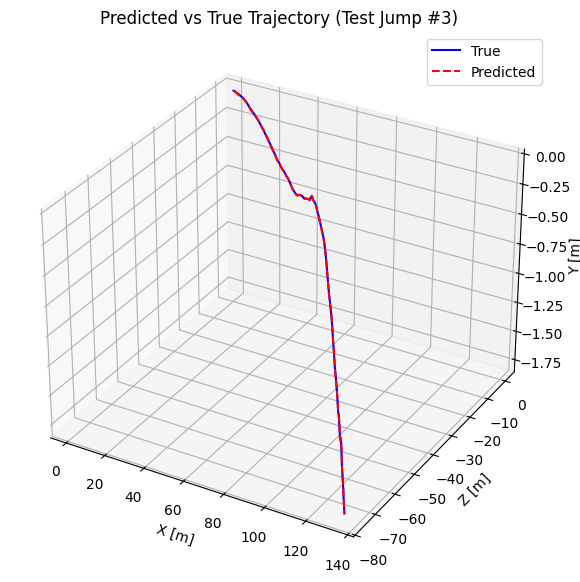

In [86]:
# Predict one step ahead
# Pick a jump from TEST set
jump_idx = 2  # try different indices
X_seq_test = X_test[jump_idx]
U_seq_test = U_test[jump_idx]

# Prepare test tensors
X_t_test = torch.tensor(X_seq_test[:-1], dtype=torch.float32)
U_t_test = torch.tensor(U_seq_test[:-1], dtype=torch.float32)
X_next_true = X_seq_test[1:]

# Predict on test data
with torch.no_grad():
    X_pred_test = model(X_t_test, U_t_test).numpy()

# Extract XYZ
true_xyz = X_next_true[:, :3]
pred_xyz = X_pred_test[:, :3]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(true_xyz[:, 0], true_xyz[:, 2], true_xyz[:, 1], label='True', color='blue')
ax.plot(pred_xyz[:, 0], pred_xyz[:, 2], pred_xyz[:, 1], label='Predicted', color='red', linestyle='--')

ax.set_xlabel("X [m]")
ax.set_ylabel("Z [m]")
ax.set_zlabel("Y [m]")
ax.set_title(f"Predicted vs True Trajectory (Test Jump #{jump_idx + 1})")
ax.legend()
plt.show()



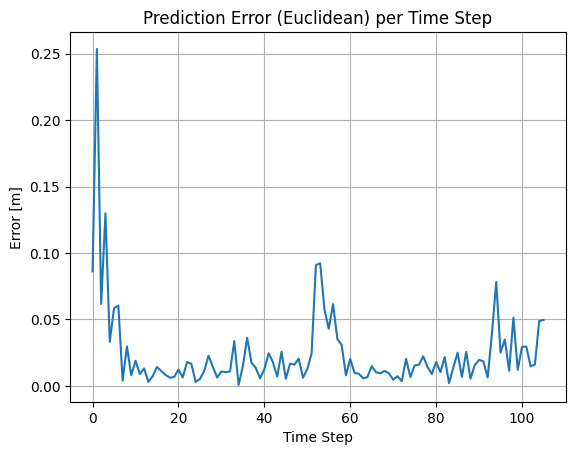

In [87]:
from numpy.linalg import norm

error = norm(pred_xyz - true_xyz, axis=1)

plt.plot(error)
plt.title("Prediction Error (Euclidean) per Time Step")
plt.xlabel("Time Step")
plt.ylabel("Error [m]")
plt.grid(True)
plt.show()
